In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

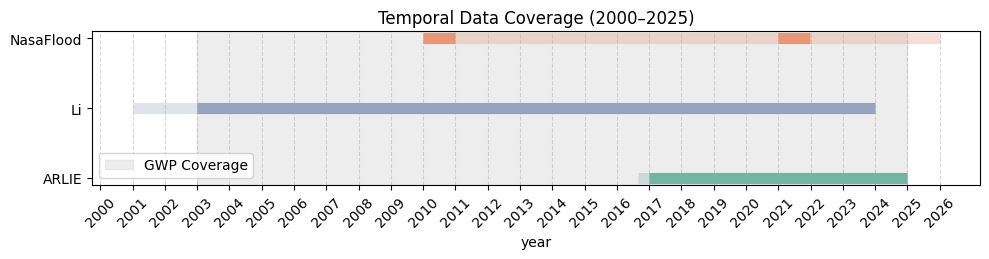

In [3]:


# Daten
data = [
    ("GWP",       "01.01.2003", "31.12.2024", None, None),
    ("ARLIE",     "01.09.2016", "31.12.2024", "01.01.2017", "31.12.2024"),
    ("Li",        "01.01.2001", "31.12.2023", "01.01.2003", "31.12.2023"),
    ("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2010", "31.12.2010"),  # volle Abdeckung + genutzte Jahre
]

# NasaFlood hat zwei Nutzzeiträume – erweitern:
# du kannst mehrere Einträge hinzufügen, um mehrere dunkle Segmente zu zeichnen
data.append(("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2021", "31.12.2021"))


df = pd.DataFrame(data, columns=["Dataset", "Start1", "End1", "Start2", "End2"])

# Datumsparsing
for col in ["Start1", "End1", "Start2", "End2"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Farben
colors = {
    "ARLIE": "#72B6A1",
    "Li": "#95A3C3",
    "NasaFlood": "#E99675",
}


# Filtere die Datasets ohne GWP
datasets = [d for d in df["Dataset"].unique() if d != "GWP"]


# Plot
fig, ax = plt.subplots(figsize=(10, 2.7))

# === GWP als grauer Hintergrund ===
gwp_row = df[df["Dataset"] == "GWP"].iloc[0]
ax.axvspan(gwp_row["Start1"], gwp_row["End1"], color="lightgrey", alpha=0.4, label="GWP Coverage")

# === Andere Datensätze ===
for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    color = colors.get(dataset)

    # hell: gesamte Abdeckung
    full_start = subset["Start1"].min()
    full_end = subset["End1"].max()
    ax.plot(
        [full_start, full_end],
        [i, i],
        lw=8,
        alpha=0.3,
        color=color,
        solid_capstyle="butt"
    )

    # dunkel: tatsächliche Zeiträume
    for _, row in subset.iterrows():
        if pd.notna(row["Start2"]) and pd.notna(row["End2"]):
            ax.plot(
                [row["Start2"], row["End2"]],
                [i, i],
                lw=8,
                alpha=1.0,
                color=color,
                solid_capstyle="butt"
            )

# y-Ticks & Labels korrekt setzen
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)


# X-Achse: jedes Jahr
years = pd.date_range("2000-01-01", "2026-01-01", freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([y.year for y in years], rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.set_xlabel("year")
ax.set_title("Temporal Data Coverage (2000–2025)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [ ]:
stats_df = pd.read_csv(r"T:\DLR\Analysis3\Results\all_stats_df.csv")
all_stats_combined = pd.read_csv(r"T:\DLR\Analysis3\Results\stats_summary.csv")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Nur Area-perc für ersten 3 Plots
df_perc = all_stats_combined[all_stats_combined['value-type'] == 'Area-perc']
# Nur Area-normalized für RMSE
df_norm = all_stats_combined[all_stats_combined['value-type'] == 'Area-normalized']

# Erste 3 Plots: Area-perc
metrics_perc = ['R2', 'spearman_cor', 'MAE']
titles_perc = ['R² (höher = besser)', 'Spearman ρ (höher = besser)', 'MAE (niedriger = besser)']

for i, (metric, title) in enumerate(zip(metrics_perc, titles_perc)):
    sns.boxplot(data=df_perc, x='Dataset', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

# 4. Plot: RMSE mit z-transformierten Daten
sns.boxplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3], palette='Set2')
axes[3].set_title('RMSE - Area-normalized\n(niedriger = besser)', fontweight='bold')
axes[3].set_xlabel('')
axes[3].set_ylabel('RMSE (z-score)')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

df_perc = all_stats_combined[all_stats_combined['value-type'] == 'Area-perc']
df_norm = all_stats_combined[all_stats_combined['value-type'] == 'Area-normalized']

# Plot 1-3: Area-perc
sns.boxplot(data=df_perc, x='Dataset', y='R2', ax=axes[0], hue = "Dataset",  palette='Set2')
axes[0].set_title('R²', fontweight='bold')

sns.boxplot(data=df_perc, x='Dataset', y='spearman_cor', ax=axes[1], hue = "Dataset",  palette='Set2')
axes[1].set_title('Spearman ρ', fontweight='bold')

sns.boxplot(data=df_perc, x='Dataset', y='RMSE', ax=axes[2], hue = "Dataset", palette='Set2')
axes[2].set_title('RMSE - LSE in %', fontweight='bold')

# Plot 4: Area-normalized RMSE
sns.boxplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3],  hue = "Dataset", palette='Set2')
axes[3].set_title('RMSE - LSE normalized', fontweight='bold')

for ax in axes:
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

df_perc = all_stats_combined[all_stats_combined['value-type'] == 'Area-perc']
df_norm = all_stats_combined[all_stats_combined['value-type'] == 'Area-normalized']

# Plot 1-3: Area-perc
sns.violinplot(data=df_perc, x='Dataset', y='R2', ax=axes[0], hue = "Dataset",  palette='Set2')
axes[0].set_title('R²', fontweight='bold')

sns.violinplot(data=df_perc, x='Dataset', y='spearman_cor', ax=axes[1], hue = "Dataset",  palette='Set2')
axes[1].set_title('Spearman ρ', fontweight='bold')

sns.violinplot(data=df_perc, x='Dataset', y='RMSE', ax=axes[2], hue = "Dataset", palette='Set2')
axes[2].set_title('RMSE - LSE in %', fontweight='bold')

# Plot 4: Area-normalized RMSE
sns.violinplot(data=df_norm, x='Dataset', y='RMSE', ax=axes[3],  hue = "Dataset", palette='Set2')
axes[3].set_title('RMSE - LSE normalized', fontweight='bold')

for ax in axes:
    ax.set_xlabel('')

plt.tight_layout()
plt.show()